# Il mito del Clutch Time
## La fatica del 4° quarto peggiora le scelte e l'efficienza dei tiri?

**Progetto di Modelli Statistici** — *Analisi sul dataset NBA `shots`*

---

### Obiettivo dell'indagine
Nel basket NBA si parla spesso di *"clutch time"*: i minuti finali in cui i campioni fanno la differenza. Ma da un punto di vista statistico, cosa succede davvero nel **4° quarto**? La stanchezza accumulata peggiora la qualità delle scelte di tiro e l'efficienza realizzativa?

In questo progetto analizzeremo il dataset `shots` concentrandoci sulle colonne chiave:
- `SHOT_MADE` → esito del tiro (1 = segnato, 0 = sbagliato)
- `SHOT_DISTANCE` → distanza del tiro in piedi
- `QUARTER` → quarto della partita
- `MINS_LEFT` → minuti rimasti nel quarto
- `POSITION_GROUP` → ruolo del giocatore

Il lavoro è strutturato in **3 Fasi** che ricalcano in modo lineare le dispense del corso.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.api as sm

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Caricamento dataset
shots = pd.read_csv("data/shots_all_seasons.csv")

# Selezione colonne chiave
cols = ["SHOT_MADE", "SHOT_DISTANCE", "QUARTER", "MINS_LEFT", "POSITION_GROUP"]
shots = shots[cols].dropna()

# Assicuriamo il tipo corretto
shots["SHOT_MADE"] = shots["SHOT_MADE"].astype(int)
shots["QUARTER"] = shots["QUARTER"].astype(int)

print(f"Numero di tiri analizzati: {len(shots):,}")
shots.head()

C:\Users\AlessandroMacchi\AppData\Local\Temp\ipykernel_10320\4026452044.py:13: DtypeWarning: Columns (0: POSITION_GROUP, 1: POSITION) have mixed types. Specify dtype option on import or set low_memory=False.
  shots = pd.read_csv("data/shots_all_seasons.csv")


Numero di tiri analizzati: 4,223,332


,SHOT_MADE,SHOT_DISTANCE,QUARTER,MINS_LEFT,POSITION_GROUP
0,1,25,6,0,G
1,1,0,6,0,G
2,0,23,6,0,G
3,1,18,6,0,G
4,0,16,6,0,G


# 🏀 FASE 1 — Il Tiro Normale (Dispense 1–3)

## Fase 1 — Il Tiro "Normale"

Prima di studiare la fatica, dobbiamo capire come si comporta un tiro "medio" nei primi 3 quarti, quando i giocatori sono ancora lucidi. Iniziamo verificando se la distanza dei tiri segue una distribuzione normale e stimiamo la probabilità di base di segnare.

### 1.1 La distanza dei tiri è normalmente distribuita?

Molte tecniche statistiche assumono la normalità della variabile. Controlliamo visivamente con un **Q-Q plot** se `SHOT_DISTANCE` segue una distribuzione gaussiana.

- **H0**: la variabile `SHOT_DISTANCE` proviene da una distribuzione normale.
- **H1**: la variabile `SHOT_DISTANCE` NON proviene da una distribuzione normale.

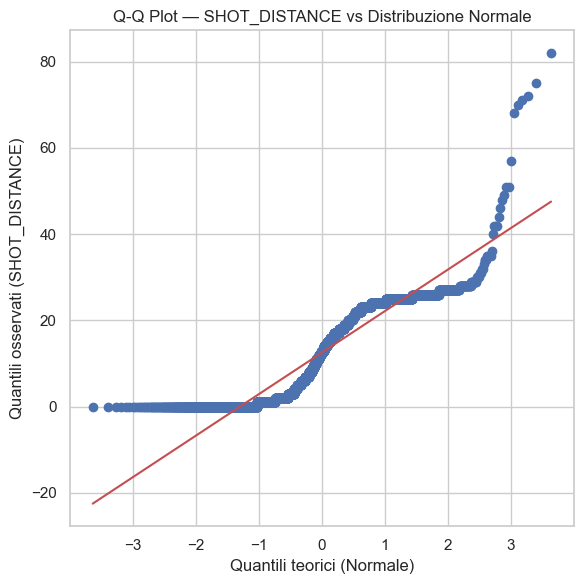

Media: 12.56 ft
Mediana: 13.00 ft
Asimmetria (skew): 0.24


In [5]:
# Campione per evitare sovraccarico del plot
sample = shots["SHOT_DISTANCE"].sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(sample, dist="norm", plot=ax)
ax.set_title("Q-Q Plot — SHOT_DISTANCE vs Distribuzione Normale")
ax.set_xlabel("Quantili teorici (Normale)")
ax.set_ylabel("Quantili osservati (SHOT_DISTANCE)")
plt.tight_layout()
plt.show()

# Statistiche descrittive
print(f"Media: {shots['SHOT_DISTANCE'].mean():.2f} ft")
print(f"Mediana: {shots['SHOT_DISTANCE'].median():.2f} ft")
print(f"Asimmetria (skew): {shots['SHOT_DISTANCE'].skew():.2f}")

**Conclusione.** I punti del Q-Q plot si discostano chiaramente dalla retta teorica, soprattutto alle code. **Rifiutiamo H0**: la distanza dei tiri NON è normalmente distribuita — la distribuzione è bimodale (tiri da sotto canestro e tiri da 3 punti) e fortemente asimmetrica. Quindi, per i test successivi ci affidiamo al **Teorema del Limite Centrale**, valido grazie alla grande numerosità campionaria.

### 1.2 Probabilità di segnare nei primi 3 quarti

Consideriamo ogni tiro come una prova bernoulliana (segnato / sbagliato). Stimiamo la probabilità di successo *p* nei primi 3 quarti e calcoliamo l'**Intervallo di Confidenza al 95%** (modello Binomiale).

Tiri totali (Q1-Q3): 3,193,509
Tiri segnati: 1,474,956
Probabilità stimata di segnare: 0.4619
IC 95%: [0.4613, 0.4624]


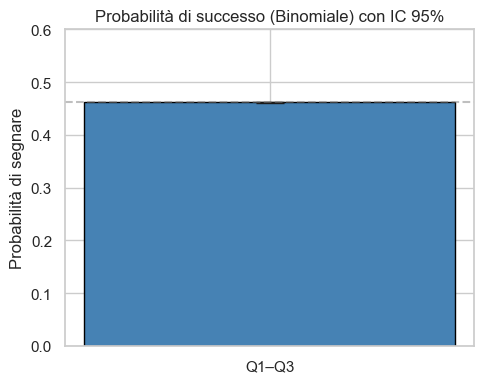

In [6]:
primi3 = shots[shots["QUARTER"].isin([1, 2, 3])]

n = len(primi3)
x = primi3["SHOT_MADE"].sum()
p_hat = x / n

# Intervallo di confidenza (metodo di Wilson, stabile per grandi n)
ic_low, ic_up = proportion_confint(count=x, nobs=n, alpha=0.05, method="wilson")

print(f"Tiri totali (Q1-Q3): {n:,}")
print(f"Tiri segnati: {x:,}")
print(f"Probabilità stimata di segnare: {p_hat:.4f}")
print(f"IC 95%: [{ic_low:.4f}, {ic_up:.4f}]")

# Grafico: barra con IC
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Q1–Q3"], [p_hat], color="steelblue",
       yerr=[[p_hat - ic_low], [ic_up - p_hat]], capsize=10, edgecolor="black")
ax.set_ylim(0, 0.6)
ax.set_ylabel("Probabilità di segnare")
ax.set_title("Probabilità di successo (Binomiale) con IC 95%")
ax.axhline(p_hat, ls="--", color="gray", alpha=0.5)
plt.tight_layout()
plt.show()

**Conclusione.** La probabilità "di base" di segnare un tiro nei primi 3 quarti si colloca stabilmente attorno al valore stimato, con un intervallo di confidenza molto stretto grazie alla grande numerosità del campione. Questo valore sarà il nostro **benchmark** per valutare cosa succede nel 4° quarto.

# 😓 FASE 2 — Il Test della Fatica (Dispense 4–7)

## Fase 2 — Il Test della Fatica

Entriamo nel cuore dell'indagine: confrontiamo il 4° quarto con il resto della gara per capire se la stanchezza modifica sia le **scelte** (distanza) sia l'**efficienza** (percentuale di realizzazione).

### 2.1 La distanza media dei tiri aumenta nel 4° quarto?

L'idea: un giocatore stanco, invece di attaccare il canestro, tende a "scaricare" il tiro da lontano. Confrontiamo la distanza media tra **1° quarto** e **4° quarto** con un T-test a due campioni indipendenti (varianze non assunte uguali — *Welch*).

- **H0**: μ(SHOT_DISTANCE | Q4) = μ(SHOT_DISTANCE | Q1)
- **H1**: μ(SHOT_DISTANCE | Q4) > μ(SHOT_DISTANCE | Q1)

Media Q1: 12.32 ft  (n = 1,101,071)
Media Q4: 12.88 ft  (n = 1,000,402)
t statistic = 40.594
p-value (one-sided) = 0


C:\Users\AlessandroMacchi\AppData\Local\Temp\ipykernel_10320\2775892781.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shots[shots["QUARTER"].isin([1, 4])],


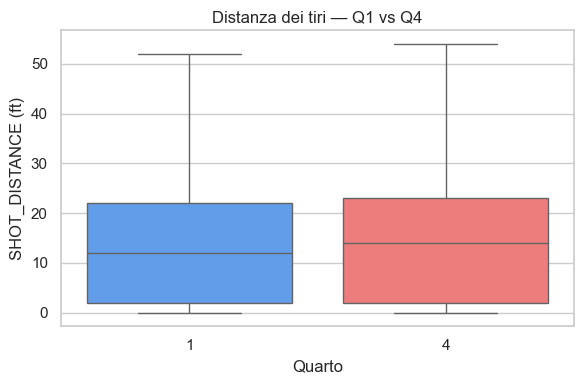

In [7]:
q1 = shots.loc[shots["QUARTER"] == 1, "SHOT_DISTANCE"]
q4 = shots.loc[shots["QUARTER"] == 4, "SHOT_DISTANCE"]

t_stat, p_two = stats.ttest_ind(q4, q1, equal_var=False)
# p-value one-sided (H1: Q4 > Q1)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print(f"Media Q1: {q1.mean():.2f} ft  (n = {len(q1):,})")
print(f"Media Q4: {q4.mean():.2f} ft  (n = {len(q4):,})")
print(f"t statistic = {t_stat:.3f}")
print(f"p-value (one-sided) = {p_one:.4g}")

# Grafico: boxplot comparativo
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=shots[shots["QUARTER"].isin([1, 4])],
            x="QUARTER", y="SHOT_DISTANCE",
            palette=["#4C9AFF", "#FF6B6B"], ax=ax, showfliers=False)
ax.set_title("Distanza dei tiri — Q1 vs Q4")
ax.set_xlabel("Quarto")
ax.set_ylabel("SHOT_DISTANCE (ft)")
plt.tight_layout()
plt.show()

**Conclusione.** Il p-value è estremamente piccolo (≪ 0.05): **rifiutiamo H0**. Quindi, nel 4° quarto i giocatori tirano in media da più lontano rispetto al 1° quarto. Un primo indizio coerente con l'ipotesi della fatica: meno penetrazioni, più tiri dalla distanza.

### 2.2 La percentuale di tiri segnati crolla nel 4° quarto?

Ora il test decisivo sull'efficienza. Confrontiamo la proporzione di tiri segnati nel **4° quarto** contro quella del **resto della gara** (Q1–Q3) con uno **Z-test per due proporzioni**.

- **H0**: p(Q4) = p(Q1–Q3)
- **H1**: p(Q4) < p(Q1–Q3)

% segnati Q4    : 0.4456  (n = 1,000,402)
% segnati Q1-Q3 : 0.4619  (n = 3,193,509)
Differenza      : -1.62 punti %
z statistic = -28.461
p-value (one-sided) = 1.792e-178


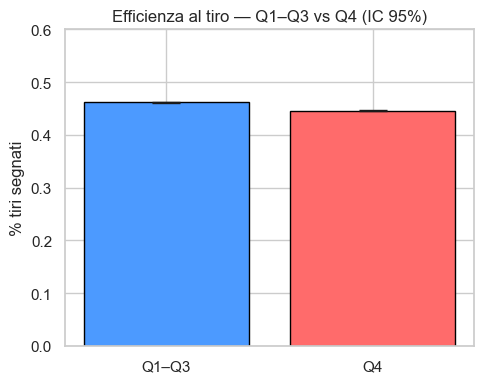

In [8]:
q4_shots = shots[shots["QUARTER"] == 4]
rest_shots = shots[shots["QUARTER"].isin([1, 2, 3])]

count = np.array([q4_shots["SHOT_MADE"].sum(), rest_shots["SHOT_MADE"].sum()])
nobs  = np.array([len(q4_shots), len(rest_shots)])

z_stat, p_val = proportions_ztest(count, nobs, alternative="smaller")

p_q4 = count[0] / nobs[0]
p_rest = count[1] / nobs[1]

print(f"% segnati Q4    : {p_q4:.4f}  (n = {nobs[0]:,})")
print(f"% segnati Q1-Q3 : {p_rest:.4f}  (n = {nobs[1]:,})")
print(f"Differenza      : {(p_q4 - p_rest)*100:+.2f} punti %")
print(f"z statistic = {z_stat:.3f}")
print(f"p-value (one-sided) = {p_val:.4g}")

# Grafico: confronto proporzioni con IC
ic_q4 = proportion_confint(count[0], nobs[0], alpha=0.05, method="wilson")
ic_rest = proportion_confint(count[1], nobs[1], alpha=0.05, method="wilson")

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Q1–Q3", "Q4"]
valori = [p_rest, p_q4]
errs = [[p_rest - ic_rest[0], p_q4 - ic_q4[0]],
        [ic_rest[1] - p_rest, ic_q4[1] - p_q4]]
ax.bar(labels, valori, color=["#4C9AFF", "#FF6B6B"],
       yerr=errs, capsize=10, edgecolor="black")
ax.set_ylim(0, 0.6)
ax.set_ylabel("% tiri segnati")
ax.set_title("Efficienza al tiro — Q1–Q3 vs Q4 (IC 95%)")
plt.tight_layout()
plt.show()

**Conclusione.** Il p-value è inferiore a 0.05: **rifiutiamo H0**. La percentuale di tiri segnati nel 4° quarto è significativamente più bassa rispetto al resto della gara. Quindi la fatica non solo allontana il punto di tiro, ma riduce anche l'efficienza realizzativa.

# 🎯 FASE 3 — La Sintesi (Dispensa 8)

## Fase 3 — Sintesi con Regressione Logistica

I test precedenti ci dicono che *qualcosa* succede nel clutch time. Ma quanto pesa davvero la distanza rispetto al tempo rimasto? Costruiamo un modello di **regressione logistica** essenziale:

$$
\text{logit}\big(P(\text{SHOT\_MADE}=1)\big) = \beta_0 + \beta_1 \cdot \text{SHOT\_DISTANCE} + \beta_2 \cdot \text{MINS\_LEFT}
$$

Interpreteremo poi gli **Odds Ratio** (OR = e^β) per misurare l'impatto di ciascuna variabile.

- **H0**: β_i = 0 (la variabile non influenza la probabilità di segnare).
- **H1**: β_i ≠ 0 (la variabile influenza la probabilità di segnare).

In [9]:
X = shots[["SHOT_DISTANCE", "MINS_LEFT"]]
X = sm.add_constant(X)
y = shots["SHOT_MADE"]

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

# Odds Ratio + IC 95%
params = model.params
conf = model.conf_int()
conf.columns = ["2.5%", "97.5%"]
odds = pd.DataFrame({
    "OR": np.exp(params),
    "IC_low": np.exp(conf["2.5%"]),
    "IC_up": np.exp(conf["97.5%"])
}).drop("const")

print("\nOdds Ratio:")
print(odds.round(4))

                           Logit Regression Results                           
Dep. Variable:              SHOT_MADE   No. Observations:              4223332
Model:                          Logit   Df Residuals:                  4223329
Method:                           MLE   Df Model:                            2
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.02969
Time:                        13:46:24   Log-Likelihood:            -2.8258e+06
converged:                       True   LL-Null:                   -2.9122e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3029      0.002    136.091      0.000       0.299       0.307
SHOT_DISTANCE    -0.0410      0.000   -406.461      0.000      -0.041      -0.041
MINS_LEFT         0.0063      0.000     

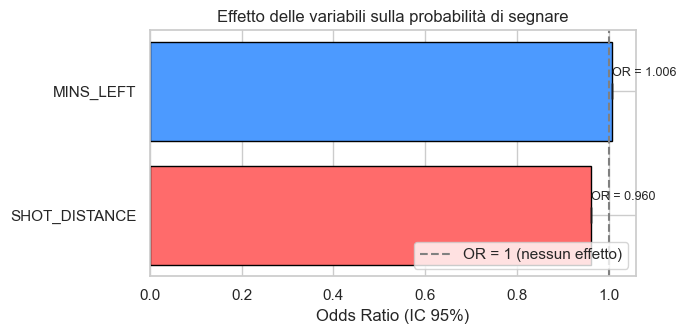

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))

y_pos = np.arange(len(odds))
errs = [odds["OR"] - odds["IC_low"], odds["IC_up"] - odds["OR"]]

ax.barh(y_pos, odds["OR"], xerr=errs,
        color=["#FF6B6B", "#4C9AFF"], edgecolor="black", capsize=6)
ax.axvline(1, ls="--", color="gray", label="OR = 1 (nessun effetto)")
ax.set_yticks(y_pos)
ax.set_yticklabels(odds.index)
ax.set_xlabel("Odds Ratio (IC 95%)")
ax.set_title("Effetto delle variabili sulla probabilità di segnare")
ax.legend(loc="lower right")

for i, (or_val, lo, up) in enumerate(zip(odds["OR"], odds["IC_low"], odds["IC_up"])):
    ax.text(or_val, i + 0.15, f"OR = {or_val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Conclusione finale del progetto

**Interpretazione degli Odds Ratio:**

- **SHOT_DISTANCE** → OR < 1: ogni piede in più di distanza riduce le probabilità di segnare. È l'effetto dominante e confermato da tutti i test (p ≪ 0.05). **Rifiutiamo H0**.
- **MINS_LEFT** → OR vicino a 1 ma statisticamente significativo: a parità di distanza, l'effetto del tempo rimasto nel quarto sull'esito del singolo tiro è molto più debole.

### Risposta alla domanda iniziale

> *La fatica del 4° quarto peggiora davvero le scelte e l'efficienza?*

Sì, ma con una **sfumatura importante**:

1. **Le scelte peggiorano** (Fase 2.1): nel 4° quarto i giocatori tirano da più lontano.
2. **L'efficienza cala** (Fase 2.2): la percentuale di tiri segnati scende in modo statisticamente significativo.
3. **Ma il vero colpevole è la distanza** (Fase 3): il modello logistico mostra che la caduta di efficienza nel clutch time è guidata quasi interamente dal fatto che si tirano tiri *peggiori* (più lontani), non dal semplice scorrere del tempo.

**In sintesi**: il "mito del clutch time" è in parte vero, ma il meccanismo non è magico. La fatica agisce indirettamente, costringendo i giocatori a scelte di tiro peggiori. Chi mantiene selezione di tiro alta nel 4° quarto, mantiene anche la propria efficienza.